# Adaptive RAG 구현

## 실습 목표
---
Adaptive RAG 챗봇을 구현하여 사용자 입력이 관련 문서와 일치하지 않는 경우 웹 검색을 통해 답변을 생성합니다.

## 실습 목차
---
1. **웹 검색 API 통합**: 웹 검색 API를 활용해서 필요한 정보를 검색하는 모듈을 구현합니다.

2. **Adaptive RAG 구현**: Self-RAG 챗봇에 웹 검색 기능을 추가하여 Adaptive RAG 챗봇을 구현하고 사용합니다.

## 0. 환경 설정
필요한 라이브러리를 불러옵니다.

In [3]:
import contextlib
import io
import os
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
from langchain_chroma import Chroma
from langchain_community.tools.tavily_search import TavilySearchResults


/var/folders/m9/22pbfsqj2k52h8fn3krgqw740000gn/T/ipykernel_65370/69068645.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [4]:
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

/Users/bkk/프로젝트/yeardream/.venv-1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from langgraph.graph import END, StateGraph
from langchain_ollama import ChatOllama, OllamaEmbeddings
from typing_extensions import TypedDict

Ollama를 통해 llama 3.1 8B 모델을 불러옵니다.

In [6]:
!ollama pull llama3.2:3B

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling dde5aa3fc5ff: 100% ▕██████████████████▏ 2.0 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 34bb5ab01051: 100% ▕██████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


In [7]:
llm = ChatOllama(model="llama3.2:3B", temperature=0)
route_llm = ChatOllama(model="llama3.2:3B", format="json", temperature=0)
embeddings = OllamaEmbeddings(model="llama3.2:3B")

Graph State를 정의합니다.

In [8]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, LLM이 생성한 텍스트, 데이터, 코드를 저장합니다.
    question: str
    generation: str
    data: str
    code: str

## 1. 웹 검색 API 통합
---
웹 검색 API를 활용해서 필요한 정보를 검색하는 모듈을 구현합니다.

Tavily Search API Key를 등록합니다.

1. 먼저, 아래 링크에 접속한 후 'Sign-in' 버튼을 눌러 로그인 화면으로 이동합니다.
   - https://app.tavily.com/sign-in
2. 여러분의 Tavily 계정으로 로그인한 후, 아래 링크에 접속하여 default API Key를 복사하여 아래 코드에 적용합니다.
   - https://app.tavily.com/home

In [9]:
# Tavily API key는 tvly- 로 시작하는 문자열입니다.
# API Key를 입력했다면, 이 셀을 실행해서 API Key를 환경 변수에 등록합니다.
os.environ["TAVILY_API_KEY"] = "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"

Tavily API 설정이 완료되었으면, 간단한 검색 기능을 구현합니다. 

Note. 간단한 구현을 위해 `max_results` 인자를 1로 설정하여 하나의 문서만 검색되도록 설정했습니다.<br>
향후 고도화 과정에서 여러 문서를 검색하고, Self-RAG 와 유사하게 문서에 순위를 매기는 기능을 추가할 수 있을 것입니다.

In [10]:
def retrieve_web(state: State) -> State:
    print("---웹 검색---")
    tavily_search_tool = TavilySearchResults(max_results=1)
    # Tavily API를 사용해 검색 결과를 가져옵니다.
    results = tavily_search_tool.invoke({"query": state["question"]})

    # 내용을 추출하여 state에 저장합니다.
    contents_list = [r['content'] for r in results]
    state["data"] = contents_list
    return state

검색 결과를 확인해봅시다.

In [11]:
retrieved_state = retrieve_web({"question": "LangChain과 LlamaIndex의 특징과 차이점은 무엇인가요?"})
print(retrieved_state["data"])

---웹 검색---


/var/folders/m9/22pbfsqj2k52h8fn3krgqw740000gn/T/ipykernel_65370/588656381.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(max_results=1)


["jeff's user avatar\n\n## 2 Comments\n\nAdd a comment\n\nLangchain is a more general-purpose framework that can be used to build a wide variety of applications. It provides tools for loading, processing, and indexing data, as well as for interacting with LLMs. Langchain is also more flexible than LlamaIndex, allowing users to customize the behavior of their applications.\n\nLlamaIndex is specifically designed for building search and retrieval applications. It provides a simple interface for querying LLMs and retrieving relevant documents. LlamaIndex is also more efficient than Langchain, making it a better choice for applications that need to process large amounts of data."]


## 2. Adaptive RAG 구현
---
Self-RAG 챗봇에 웹 검색 기능을 추가하여 Adaptive RAG 챗봇을 구현하고 사용합니다.

### 2.1. Self-RAG 챗봇 구현
간략화한 Self-RAG 챗봇을 구현합니다. 이를 위해 검색 과정에서의 문서와 답변을 평가하는 함수를 정의합니다.

In [12]:
# 정보 평가
def is_data_relevant(state: State) -> dict:
    # LLM이 생성한 텍스트가 문서와 관련이 있는지 확인합니다.
    print("--- is_data_relevant ---")
    question = state["question"]
    data = state["data"]
    system_message = """당신은 검색된 문서와 사용자의 질문의 연관성을 평가하는 평가자입니다.
다음은 검색된 문서입니다: \n{data}\n.
문서와 사용자가 입력할 질문이 연관이 있다면 `yes`, 그렇지 않다면 `no`를 선택하세요.
답변은 'relevant' key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", "{question}"))

    relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # 로직 선택용 ChatOllama 객체를 생성합니다. format="json" 인자를 적용하여 출력 양식을 json으로 강제합니다.
    # 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
    router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "data": data})
    print(result)
    return result

# 정보 평가
def is_answer_supportive(state: State) -> dict:
    # 생성된 텍스트가 질문과 관련이 있는지 확인합니다.
    question = state["question"]
    generation = state["generation"]
    system_message = (
        """당신은 AI의 답변이 사용자의 질문에 대한 해답인지 평가하는 평가자입니다."""
    )
    # 다른 모듈과 달리, 정보와 AI의 답변을 모두 사용자 프롬프트에 추가합니다. 이는 실험을 통해 더 좋은 결과가 나와서 선택한 방법입니다.
    # 또한 함수 이름과 달리 'supportive'가 아니라 'answer' Key에 답변을 저장하라는 지시가 있습니다.
    # 이는 다른 지시사항에 있는 텍스트와 일관성을 유지하기 위함입니다.
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자의 질문에 대한 해답이면 'yes', 아니라면 'no'를 선택하세요.
'answer' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # 로직 선택용 ChatOllama 객체를 생성합니다. format="json" 인자를 적용하여 출력 양식을 json으로 강제합니다.
    # 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
    router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "generation": generation})
    return result

# 유용성 평가
def is_answer_useful(state: State) -> dict:
    # 생성된 텍스트가 질문에 대한 해답인지 확인합니다.
    question = state["question"]
    generation = state["generation"]
    system_message = """당신은 AI의 답변이 사용자에게 유용한지 평가하는 평가자입니다."""
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자에게 유용하다면 'yes', 아니라면 'no'를 선택하세요.
'useful' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    useful_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # 로직 선택용 ChatOllama 객체를 생성합니다. format="json" 인자를 적용하여 출력 양식을 json으로 강제합니다.
    # 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
    router_chain = useful_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "generation": generation})
    return result

In [13]:
# 할루시네이션 평가
def is_hallucinated(state: State) -> dict:
    # 생성된 텍스트가 질문에 대한 해답인지 확인합니다.
    generation = state["generation"]
    docs = state["data"]
    system_message = """당신은 주어진 근거 문서를 바탕으로 AI의 답변이 진실인지 여부를 평가하는 평가자입니다."""
    user_message = """근거 문서: {docs}
AI의 답변: {generation}
근거 문서를 바탕으로 AI의 답변이 진실이라면 True, 아니라면 False를 선택하세요.
'answer` key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    hallucination_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # 로직 선택용 ChatOllama 객체를 생성합니다. format="json" 인자를 적용하여 출력 양식을 json으로 강제합니다.
    # 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
    router_chain = hallucination_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"generation": generation, "docs": docs})
    print(result)
    return result

데이터를 불러오고, 유틸리티 함수를 정의합니다.

In [14]:
excel_data_name = "한국지능정보사회진흥원_인공지능 학습용 데이터 구축 현황_20210104.csv"
pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"

# 데이터를 불러오고, 이름과 컬럼명을 저장합니다.
data_dir = "./data"
df_ai_train_data_dist = pd.read_csv(
    os.path.join(data_dir, excel_data_name), index_col=None
)

# 데이터를 저장한 변수명을 LLM에 제공하여 이 변수를 활용하는 코드를 작성하게 할 수 있습니다.
df_name = "df_ai_train_data_dist"
df_columns = ", ".join(df_ai_train_data_dist.columns)


# 시장 조사 문건을 불러옵니다.
vectorstore = Chroma(
    embedding_function=embeddings, persist_directory="./vectorstore/chroma"
)

db_retriever = vectorstore.as_retriever()


# LLM이 생성한 코드를 파싱하는 함수를 정의합니다.
def python_code_parser(input: str) -> str:
    # LLM은 대부분 ``` 블럭 안에 코드를 출력합니다. 이를 활용합니다.
    # ```python (코드) ```, 혹은 ``` (코드) ``` 형태로 출력됩니다. 두 경우 모두에 대응하도록 코드를 작성합니다.
    processed_input = input.replace("```python", "```").strip()
    parsed_input_list = processed_input.split("```")

    # 만약 ``` 블럭이 없다면, 입력 텍스트 전체가 코드라고 간주합니다.
    # 아닐 경우 이어지는 코드 실행 과정에서 예외 처리를 통해 오류를 확인할 수 있습니다.
    if len(parsed_input_list) == 1:
        return processed_input

    # 코드 부분만 추출합니다.
    # LLM은 여러 코드 블럭에 걸쳐 필요한 코드를 출력할 수 있으므로, 코드가 있는 홀수 번째 텍스트를 모두 저장합니다.
    parsed_code_list = []
    for i in range(1, len(parsed_input_list), 2):
        parsed_code_list.append(parsed_input_list[i])

    # 코드 부분을 하나로 합칩니다.
    return "\n".join(parsed_code_list)


# 생성한 코드를 실행하는 함수를 정의합니다.
def run_code(input_code: str):
    output = io.StringIO()
    try:
        with contextlib.redirect_stdout(output):
            # 코드가 실행하면서 출력한 모든 결과를 캡쳐합니다.
            exec(input_code, {"df_ai_train_data_dist": df_ai_train_data_dist})
    except Exception as e:
        # 에러가 발생할 경우, 이를 StringIO 객체에 저장합니다.
        print(f"Error: {e}", file=output)
    # StringIO 객체에 저장된 값을 반환합니다.
    return output.getvalue()

단순 답변, 엑셀 데이터 분석, RAG 기능을 구현합니다.
- 대화 기억 기능, 데이터 그래프 작성 기능은 이번 실습에서 사용하지 않습니다.

In [15]:
def query(state: State) -> State:
    # 데이터를 쿼리하는 코드를 생성하고, 실행하고, 그 결과를 포함한 State를 반환합니다.

    print("---데이터 쿼리---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]

    # Retrieval
    system_message = """당신은 주어진 데이터를 분석하는 데이터 분석가입니다.
주어진 DataFrame에서 데이터를 출력하여 주어진 질문에 답할 수 있는 파이썬 코드를 작성하세요.
{df_name} DataFrame에 액세스할 수 있습니다.
`{df_name}` DataFrame에는 다음과 같은 열이 있습니다: {df_columns}
데이터는 이미 로드되어 있으므로 데이터 로드 코드를 생략해야 합니다."""

    message_with_data_info = [
        ("system", system_message),
        ("human", "{question}"),
    ]

    prompt_with_data_info = ChatPromptTemplate.from_messages(message_with_data_info)

    # 체인을 구성합니다.
    code_generate_chain = (
        {"question": RunnablePassthrough()}
        | prompt_with_data_info
        | llm
        | StrOutputParser()
        | python_code_parser
    )
    code = code_generate_chain.invoke(question)
    data = run_code(code)
    return {"question": question, "code": code, "data": data, "generation": code}


def answer_with_data(state: State) -> State:
    # 쿼리한 데이터를 바탕으로 답변을 생성합니다.
    print("---데이터 기반 답변 생성---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]
    data = state["data"]

    # 데이터를 바탕으로 질문에 대답하는 코드를 생성합니다.
    reasoning_system_message = "당신은 데이터를 바탕으로 질문에 답하는 데이터 분석가입니다. 사용자가 입력한 데이터를 바탕으로, 질문에 대답하세요."
    reasoning_user_message = "데이터: {data}\n{question}"

    reasoning_with_data = [
        ("system", reasoning_system_message),
        ("human", reasoning_user_message),
    ]
    reasoning_with_data_chain = (
        ChatPromptTemplate.from_messages(reasoning_with_data) | llm | StrOutputParser()
    )

    # 대답 생성
    generation = reasoning_with_data_chain.invoke({"data": data, "question": question})
    return {
        "question": question,
        "code": state["code"],
        "data": data,
        "generation": generation,
    }


def answer(state: State) -> State:
    # 데이터를 쿼리하지 않고 답변을 바로 생성합니다.
    print("---답변 생성---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]

    return {"question": question, "generation": llm.invoke(question).content}


def retrieval(state: State) -> State:
    # 문서 검색을 수행합니다.

    def get_retrieved_text(docs):
        result = "\n".join([doc.page_content for doc in docs])
        return result

    print("---데이터 검색---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]

    # Retrieval Chain
    retrieval_chain = db_retriever | get_retrieved_text

    data = retrieval_chain.invoke(question)

    return {"question": question, "data": data}


def answer_with_retrieved_data(state: State) -> State:
    # 검색한 문서를 바탕으로 답변을 생성합니다.
    print(
        "---검색된 데이터를 바탕으로 답변 생성---"
    )  # 현재 상태를 확인하기 위한 Print문

    question = state["question"]
    data = state["data"]

    messages_with_contexts = [
        ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
        ("human", "정보: {data}. 를 바탕으로 \n{question}. 질문에 답하세요."),
    ]
    prompt_with_context = ChatPromptTemplate.from_messages(messages_with_contexts)

    # 체인 구성
    qa_chain = prompt_with_context | llm | StrOutputParser()

    generation = qa_chain.invoke({"data": data, "question": question})
    return {"question": question, "data": data, "generation": generation}

초기 라우팅 함수를 정의합니다.

웹 검색 기능이 추가되었으므로, 라우팅 함수의 시스템 프롬프트에도 이를 반영합니다.

In [16]:
def init_answer(state: State) -> State:
    # 초기 질문의 경로를 결정합니다.        
    route_system_message = """당신은 사용자의 질문에 RAG, 엑셀 데이터, 웹 검색 중 어떤 것을 활용할 수 있는지 결정하는 전문가입니다.
인공지능 산업 동향과 관련된 질문이라면 RAG를 활용하세요.
인공지능 데이터 프로필과 관련된 질문이라면 excel_data를 활용하세요.
둘 다 아니지만 추가 정보가 필요하다면 web_search를 활용하세요.
전부 아니라면, plain_answer로 충분합니다.
주어진 질문에 맞춰 `rag`, `excel_data`, `web_search`, `plain_answer`중 하나를 선택하세요.
답변은 `route` key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
    route_user_message = "{question}"
    route_prompt = ChatPromptTemplate.from_messages(
        [("system", route_system_message), ("human", route_user_message)]
    )

    router_chain = route_prompt | route_llm | JsonOutputParser()

    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    return {"question": question, "generation": route}

앞서 구성한 모듈을 모두 활용하여 그래프를 구성합니다.

In [17]:
## 그래프 구성
# 그래프를 구성하기 위해 StateGraph 객체를 생성합니다.
# 생성자의 인자로 State를 전달하여 Node 간에 정보를 전달할 때 State type을 사용함을 명시합니다.
workflow = StateGraph(State)
# 앞서 정의한 Node를 모두 추가합니다.
workflow.add_node("init_answer", init_answer)

workflow.add_node("excel_data", query)
workflow.add_node("rag", retrieval)
workflow.add_node("web_search", retrieve_web)
workflow.add_node("answer_with_data", answer_with_data)
workflow.add_node("plain_answer", answer)

# 서로 다른 이름의 노드에 같은 함수를 추가했습니다. 이는 웹 검색 기반 답변에서는 별도의 검증 과정을 거치기 때문입니다.
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)
workflow.add_node("answer_with_web_retrieval", answer_with_retrieved_data)

# 시작지점을 정의합니다.
workflow.set_entry_point("init_answer")

# 간선을 정의합니다.
# END는 종결 지점을 의미합니다.
workflow.add_edge("plain_answer", END)
workflow.add_edge("answer_with_data", END)
workflow.add_edge("excel_data", "answer_with_data")


# 조건부 간선을 정의합니다.
# 1. 검색 여부를 결정합니다.
workflow.add_conditional_edges(
    "init_answer",
    lambda state: state["generation"]
    .lower()
    .strip(),  # 라우팅 결과를 추출하는 함수를 lambda로 정의합니다.
    # 어떤 노드로 이동할지 mapping합니다.
    {
        "excel_data": "excel_data",
        "rag": "rag",
        "plain_answer": "plain_answer",
        "web_search": "web_search",
    },
)

# 웹 검색 결과의 연관성을 평가합니다.
workflow.add_conditional_edges(
    "web_search",
    lambda state: is_data_relevant(state)["relevant"],
    {
        "yes": "answer_with_web_retrieval",
        "no": "plain_answer",
    },
)


# 2. 탐색한 문서의 연관성을 평가합니다.
# `no`라면 검색한 데이터를 파기하고 plain_answer로 이동합니다.
workflow.add_conditional_edges(
    "rag",
    lambda state: is_data_relevant(state)["relevant"],
    {
        "yes": "answer_with_retrieval",
        "no": "plain_answer",
    },
)

# 3. 생성된 답변의 지지 여부와 할루시네이션 여부를 평가합니다.
# 이때, 각 함수가 이상한 답변을 생성할 경우 평가를 생략합니다.
def judge_answer(state: State) -> str:
    print("---답변 평가---")  # 현재 상태를 확인하기 위한 Print문    
    try:
        hallucinated = is_hallucinated(state)["answer"]
        # change string to boolean
        if type(hallucinated) == str:
            hallucinated = hallucinated.lower() == "true"
        print(
            "---주어진 답변은" + " 진실입니다.---"
            if hallucinated == True
            else " 진실이 아닙니다.---"
        )
    except KeyError:
        hallucinated = True
        print("---주어진 답변이 진실인지 알 수 없습니다.---")

    if not hallucinated:
        return "hallucinated"    

    try:
        supportive = is_answer_supportive(state)["answer"]
        print(
            "---주어진 답변은 " + "지원적입니다.---"
            if supportive == "yes"
            else " 지원적이지 않습니다.---"
        )
    except KeyError:
        supportive = "yes"
        print("---주어진 답변이 지원적인지 알 수 없습니다.---")

    try:
        useful = is_answer_useful(state)["useful"]
        print(
            "---주어진 답변은" + " 유용합니다.---"
            if useful == "yes"
            else " 유용하지 않습니다.---"
        )
    except KeyError:
        useful = "yes"
        print("---주어진 답변이 유용한지 알 수 없습니다.---")

    if (supportive == "yes" or useful == "yes") and hallucinated == True:
        return "yes"
    else:
        return "no"


# `yes` 라면 종결 지점으로 이동합니다.
# `no`라면 검색한 데이터를 파기하고 plain_answer로 이동합니다.
# `hallucinated`라면 검색한 데이터를 파기하고 재생성합니다.
workflow.add_conditional_edges(
    "answer_with_retrieval",
    judge_answer,
    {
        "yes": END,
        "no": "plain_answer",
        "hallucinated": "answer_with_retrieval",
    },
)

# 웹 검색 결과를 바탕으로 답변을 평가합니다. 이때, 할루시네이션이 의심된다면 재생성하는 대신 검색부터 다시 시작합니다.
workflow.add_conditional_edges(
    "answer_with_web_retrieval",
    judge_answer,
    {
        "yes": END,
        "no": "plain_answer",
        "hallucinated": "web_search",
    },
)

graph = workflow.compile()

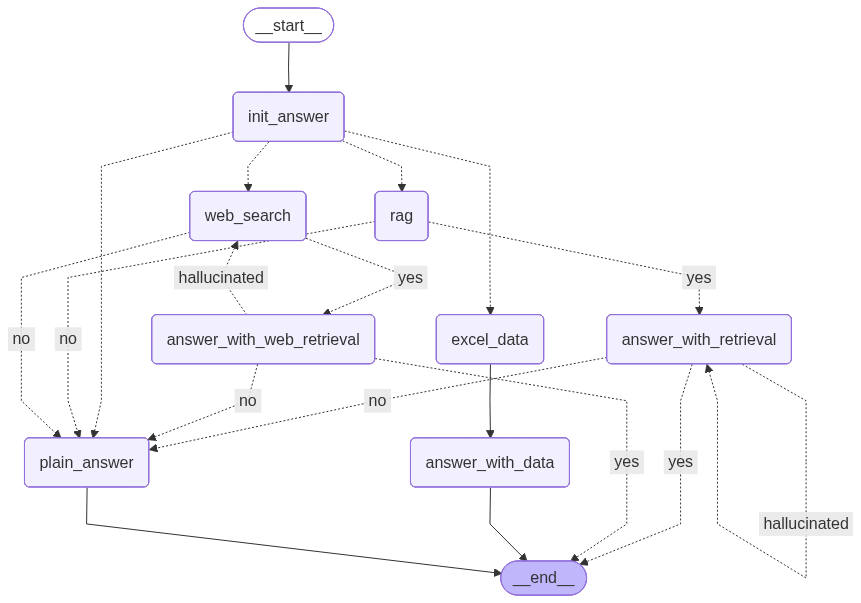

In [18]:
graph

모델 구성을 끝마쳤으면, 한번 사용해 봅시다.

Note. LLM 특성상 의도하지 않은 방식으로 작동하지 않을 가능성이 있습니다.

In [19]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        # graph.invoke 함수를 사용하여 그래프를 실행하고, 최종 결과를 반환합니다.
        # 답변 생성에는 약 1분 정도 소요됩니다.
        try:
            print(
                "Assistant: ",
                graph.invoke({"question": question})["generation"],
            )
        except Exception as e:
            print("Assistant: 오류가 발생했습니다. 다시 시도해주세요.")
            print(e)

---웹 검색---
--- is_data_relevant ---
{'relevant': 'yes'}
---검색된 데이터를 바탕으로 답변 생성---
---답변 평가---
{'answer': 'True'}
---주어진 답변은 진실입니다.---
---주어진 답변은 지원적입니다.---
 유용하지 않습니다.---
Assistant:  2023년 국내외 인공지능 산업 동향은 급격히 변화하고 있는 industry로, 생성AI 기술의 발전과 관련된 사회적 부작용 등이 국제사회에서 주목을 받고 있습니다.

2022년 11월에 등장한 오픈AI社의 챗GPT(ChatGPT) 이후 인공지능 기술은 다시 한 번 역사적 변곡점을 맞이했습니다. 이로 인해 관련 하드웨어, 서비스 개발에 대한 투자뿐만 아니라 전산업에서 AI융합이 본격화되고 있으며 글로벌 빅테크를 중심으로 한 주도권 경쟁이 치열해 지고 있습니다.

한편, 확률적 산출물 조합에 기반한 생성AI 기술의 한계와 생성물의 오남요에 따른 사회적 부작용 등 AI에 대한 국제사회에서의 규제 움직임도 점차 가시화되고 있습니다. 이러한 상황에서, 알파고(AlphaGo)이후 2010년 중반부터 급격히 진행되고 있는 인공지능 기술의 진화와 함께 사회적, 제도적 추이를 지속적으로 파악하여 시의성 있게 대응하는 정책적 민첩성의 요구가 높아졌습니다.

2023년 국내외 인공지능 산업 동향 연구는 이러한 급변하는 industry를 파악하여 국내 산업 경쟁력 강화와 인공지능 활용 확산을 위한 정책 자료를 확보하는 것이 기본 목표입니다. 주요국, 기관, 학술단체, 주요 기업의 동향을 파악하여 현황을 진단하고, 향후 AI 기술의 발전과 산업을 전망하여 시의적절한 AI 정책을 개발하고 의사결정을 지원할 수 있도록 기초 자료 제공 및 정책 과제 발굴에 활용합니다.
---웹 검색---
--- is_data_relevant ---
{'relevant': 'yes'}
---검색된 데이터를 바탕으로 답변 생성---


KeyboardInterrupt: 